#Student Performance Analysis Project
##By OSOO ISHMAELDA DAMAR ACHIENG
This project explores the factors affecting student performance in a Portuguese language course.The goal is to identify key drivers of success and understand how social habits impact final grades.

In [15]:
import pandas as pd
#Load your student performance dataset
df =pd.read_csv('student-por.csv')
#Display the first 5 rows 
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


First we load the dataset and take a quick look at the first few rows to ensure the data is structured correctly.

In [16]:
%pip install pandas


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
#check for missing values in each column
df.isnull().sum(axis=0)

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

We check for any missing values to ensure our analysis is based on complete dataset

In [18]:
num_cols= df.select_dtypes(include=['number']).columns.tolist()
cat_cols =df.select_dtypes(include=['object']).columns.tolist()
print("---NUMERICAL COLUMNS---")
print(num_cols)
print("\n---CATEGORICAL COLUMNS---")
print(cat_cols)

---NUMERICAL COLUMNS---
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

---CATEGORICAL COLUMNS---
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16680\2943939208.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols =df.select_dtypes(include=['object']).columns.tolist()


In [19]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


In [20]:
df.groupby('studytime')['G3'].mean()

studytime
1    10.844340
2    12.091803
3    13.226804
4    13.057143
Name: G3, dtype: float64

In [21]:
social_impact=df[['goout','Dalc','Walc','absences','G3']].corr()
print("Correlation with Final Grade(G3):")
print(social_impact['G3'].sort_values(ascending=False))

Correlation with Final Grade(G3):
G3          1.000000
goout      -0.087641
absences   -0.091379
Walc       -0.176619
Dalc       -0.204719
Name: G3, dtype: float64


##the impact of absences

In [22]:
family_impact=df[['Medu','Fedu','studytime','G3']].corr()
print("Impact on Final Grade (G3):")
print(family_impact['G3'].sort_values(ascending=False))

Impact on Final Grade (G3):
G3           1.000000
studytime    0.249789
Medu         0.240151
Fedu         0.211800
Name: G3, dtype: float64


##correlation analysis

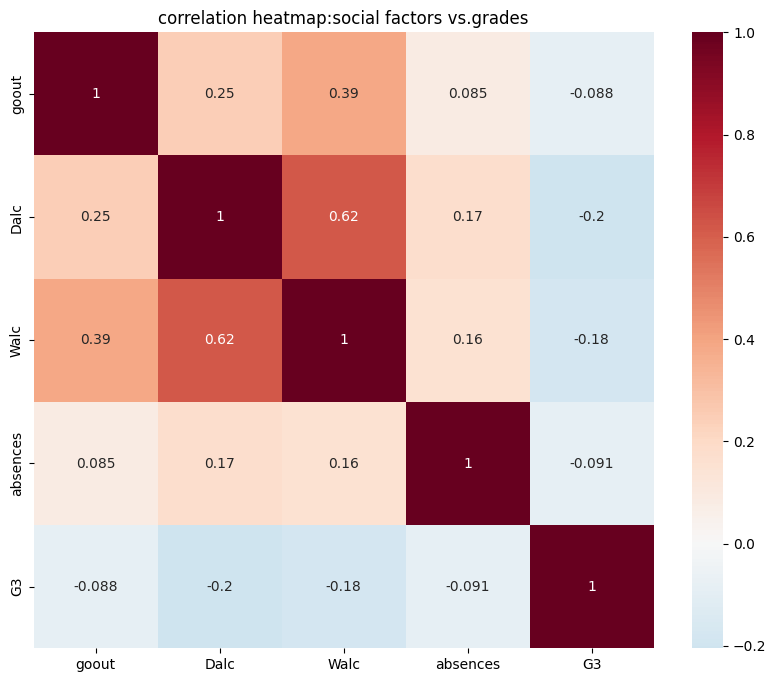

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
#create a heatmap
plt.figure(figsize=(10,8))
sns.heatmap(social_impact,annot=True,cmap='RdBu_r',center=0)
plt.title('correlation heatmap:social factors vs.grades')
plt.show()

##using a heatmap,we visualize the relationship between social factors and final grade(G3).Anegative correlation indicates that as the factor increases,grades tend to decrease.

In [24]:
!python -m pip install seaborn matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
#create "bins" for absences(0-5,6-10,11-20,20+)
df['absence_brackets']=pd.cut(df['absences'], bins=[0,5,10,20,100],labels=['0-5','6-10','11-20','20+'])
#calculate the average grade for each bracket
threshold_analysis=df.groupby('absence_brackets',observed=True)['G3'].mean()
print("Average Grade by Absence Bracket:")
print(threshold_analysis)

Average Grade by Absence Bracket:
absence_brackets
0-5      12.055556
6-10     11.852459
11-20    10.634146
20+      10.750000
Name: G3, dtype: float64


##To dig deeper,we grouped students into 'absence brackets' to see exactly where performance begins to drop off.

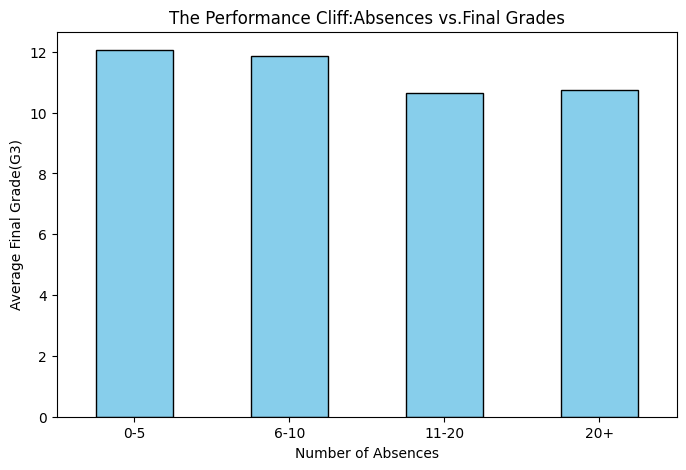

In [26]:
plt.figure(figsize=(8,5))
threshold_analysis.plot(kind='bar',color='skyblue',edgecolor='black')
plt.title('The Performance Cliff:Absences vs.Final Grades')
plt.xlabel('Number of Absences')
plt.ylabel('Average Final Grade(G3)')
plt.xticks(rotation=0)
plt.show()

##A bar chart clearly shows the average grade for each group of students based on their attendance records.